# 07 — Rear-Axle Analysis: Monaco GP 2026 Q

Goal of this notebook:
1. Apply the rear-axle pipeline to the same Monaco Q pole lap analyzed in Phase 1a
2. Decompose rear-axle braking into regen and friction shares
3. Directly compare front and rear disc thermal cycles at the same circuit
4. Sensitivity analysis on the rear lumped convective conductance ($h_{eff,0,rear}$)
5. Identify the calibration regime in which the model produces physically sensible rear-disc operating temperatures

## Headline finding (preview)

At default rear-cooling parameters ($h_{eff,0,rear} = 60$ W/K, geometrically scaled from front), the model predicts **rear discs running below the carbon-carbon working window** (~150-200°C minimum) at Monaco Q: T_min ≈ 103°C, T_mean ≈ 142°C, T_max ≈ 191°C. This is not a model bug — it surfaces a known 2026 problem where teams must actively *block* rear cooling ducts to keep discs warm enough to function. The sensitivity sweep identifies the rear cooling conductance at which the model's rear discs reach a defensible operating window, providing an indirect calibration anchor in the absence of public ground truth.

## Why this analysis matters for the paper

The "2026 cars are different" claim in the project's framing rests almost entirely on the rear axle, because:
- Front brakes operate the same way they always have (pure friction)
- Rear brakes now share work with the MGU-K's 350 kW regenerative braking
- The brake-by-wire control system that splits friction from regen has no analog in pre-2026 cars

This notebook produces the first quantitative model prediction of how the 2026 rear thermal landscape differs from what a "front-only" analysis would suggest.

In [1]:
#Setup

import sys
sys.path.insert(0, '..')

import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import fastf1

from src.analysis.rear_pipeline import run_session_rear
from src.utils import constants as C

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

fastf1.Cache.enable_cache('../data/raw')

# Load Phase 1a front-axle result from the precomputed pickle
with open('../data/precomputed/2026_Monaco_Q.pkl', 'rb') as f:
    r_front = pickle.load(f)

# Run rear-axle analysis with default parameters
r_rear = run_session_rear(2026, 'Monaco', 'Q', verbose=False)

print("Front-axle (Phase 1a) headline:")
print(f"  T:    min={r_front['T_min_C']:.0f}°C, mean={r_front['T_mean_C']:.0f}°C, max={r_front['T_max_C']:.0f}°C")
print(f"  Wear: {r_front['wear_total_mg_per_disc']:.1f} mg per disc per lap")
print(f"  E:    {r_front['E_per_disc_MJ']:.2f} MJ per disc per lap")
print()
print("Rear-axle (Phase 1b chunk 2) headline:")
print(f"  T:    min={r_rear['T_rear_min_C']:.0f}°C, mean={r_rear['T_rear_mean_C']:.0f}°C, max={r_rear['T_rear_max_C']:.0f}°C")
print(f"  Wear: {r_rear['wear_total_mg_per_rear_disc']:.2f} mg per disc per lap")
print(f"  E_rear_total: {r_rear['E_brake_rear_total_J']/1e6:.2f} MJ")
print(f"    of which regen: {r_rear['E_regen_total_J']/1e6:.2f} MJ ({r_rear['regen_fraction_lap']*100:.1f}%)")
print(f"    of which friction: {r_rear['E_friction_rear_total_J']/1e6:.2f} MJ ({(1-r_rear['regen_fraction_lap'])*100:.1f}%)")

core           INFO 	Loading data for Monaco Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
core           INFO 	Finished loading data for 22 drivers: ['12', '3', '44', '16', '6', '63', '81', '1', '10', '30', '23', '55', '27', '43', '41', '5', '31', '11', '87', '77', '14', '18']


Front-axle (Phase 1a) headline:
  T:    min=567°C, mean=715°C, max=798°C
  Wear: 27.0 mg per disc per lap
  E:    2.73 MJ per disc per lap

Rear-axle (Phase 1b chunk 2) headline:
  T:    min=103°C, mean=142°C, max=191°C
  Wear: 3.33 mg per disc per lap
  E_rear_total: 4.09 MJ
    of which regen: 3.43 MJ (83.7%)
    of which friction: 0.67 MJ (16.3%)


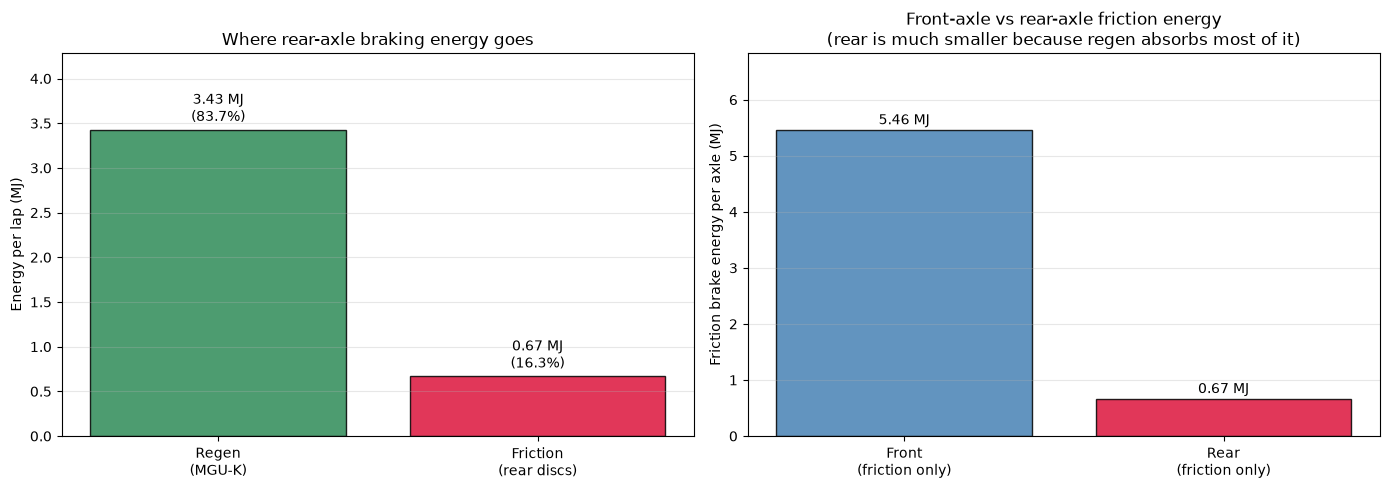


Front-axle friction energy: 5.46 MJ
Rear-axle friction energy:  0.67 MJ
Ratio (rear / front):       0.12

This ratio captures the fundamental 2026 change: the rear axle still
absorbs ~44% of total brake energy, but ~84% of that goes to regen,
so the rear friction brakes only see ~12% of front friction energy.


In [2]:
#Rear-axle energy budget

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: rear-axle energy split (regen vs friction) ─────────────────
labels = ['Regen\n(MGU-K)', 'Friction\n(rear discs)']
values = [r_rear['E_regen_total_J'] / 1e6,
           r_rear['E_friction_rear_total_J'] / 1e6]
colors = ['seagreen', 'crimson']
axes[0].bar(labels, values, color=colors, alpha=0.85, edgecolor='black')
for i, v in enumerate(values):
    pct = v / sum(values) * 100
    axes[0].text(i, v + 0.1, f'{v:.2f} MJ\n({pct:.1f}%)',
                  ha='center', fontsize=10)
axes[0].set_ylabel('Energy per lap (MJ)')
axes[0].set_title('Where rear-axle braking energy goes')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim(0, max(values) * 1.25)

# ── Right: front vs rear energy comparison ───────────────────────────
front_energy_total = r_front['E_per_disc_MJ'] * 2  # 2 discs front
rear_friction_total = r_rear['E_friction_rear_total_J'] / 1e6
labels2 = ['Front\n(friction only)', 'Rear\n(friction only)']
values2 = [front_energy_total, rear_friction_total]
axes[1].bar(labels2, values2, color=['steelblue', 'crimson'],
              alpha=0.85, edgecolor='black')
for i, v in enumerate(values2):
    axes[1].text(i, v + 0.1, f'{v:.2f} MJ', ha='center', fontsize=10)
axes[1].set_ylabel('Friction brake energy per axle (MJ)')
axes[1].set_title('Front-axle vs rear-axle friction energy\n'
                   '(rear is much smaller because regen absorbs most of it)')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_ylim(0, max(values2) * 1.25)

plt.tight_layout()
plt.show()

print(f"\nFront-axle friction energy: {front_energy_total:.2f} MJ")
print(f"Rear-axle friction energy:  {rear_friction_total:.2f} MJ")
print(f"Ratio (rear / front):       {rear_friction_total / front_energy_total:.2f}")
print(f"\nThis ratio captures the fundamental 2026 change: the rear axle still")
print(f"absorbs ~{C.BETA_REAR*100:.0f}% of total brake energy, but ~84% of that goes to regen,")
print(f"so the rear friction brakes only see ~{rear_friction_total/front_energy_total*100:.0f}% of front friction energy.")

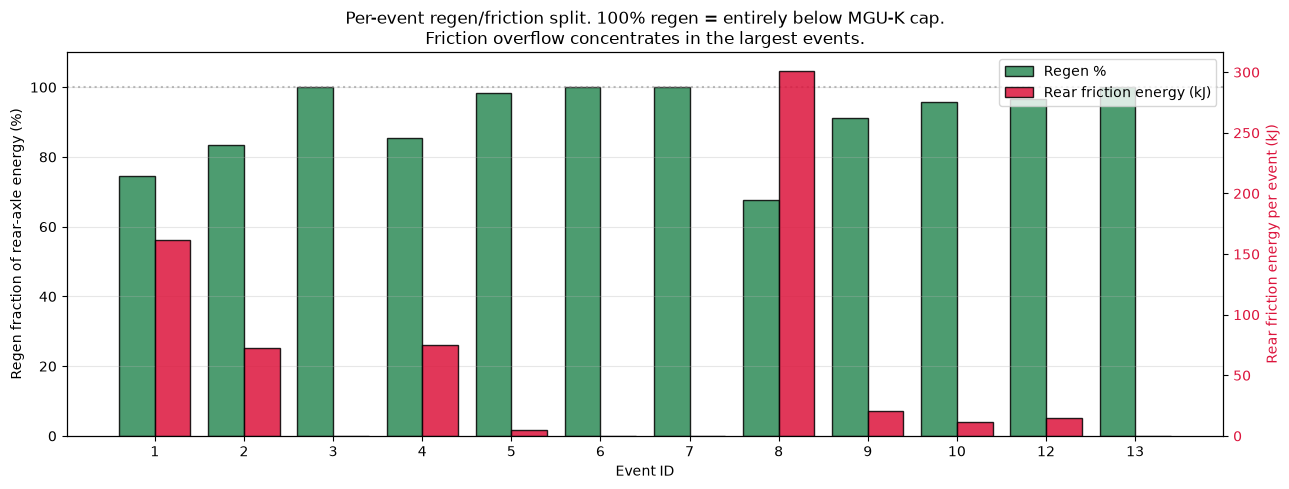


Observation: events 3, 6, 7, 13 are at 100% regen — small events where peak
power never reaches the 350 kW MGU-K cap. The big events (1, 4, 8, 12) are where
the cap binds and friction overflow concentrates. Event 8 (Nouvelle Chicane) has
the lowest regen fraction because it has the highest peak rear-axle power.


In [3]:
#Per-event regen fractions

events = r_rear['events']
event_ids = [ev['event_id'] for ev in events]
regen_frac = r_rear['regen_fraction_per_event'] * 100
E_friction = r_rear['E_friction_rear_per_event_J'] / 1000  # kJ

fig, ax1 = plt.subplots(figsize=(13, 5))

x = np.arange(len(event_ids))
width = 0.4

# Bar plot: regen fraction per event
bars1 = ax1.bar(x - width/2, regen_frac, width,
                 color='seagreen', alpha=0.85, edgecolor='black',
                 label='Regen %')
ax1.axhline(100, color='gray', linestyle=':', alpha=0.5)
ax1.set_xlabel('Event ID')
ax1.set_ylabel('Regen fraction of rear-axle energy (%)')
ax1.set_xticks(x)
ax1.set_xticklabels(event_ids)
ax1.set_ylim(0, 110)
ax1.grid(True, alpha=0.3, axis='y')

# Twin axis: friction energy per event
ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, E_friction, width,
                 color='crimson', alpha=0.85, edgecolor='black',
                 label='Rear friction energy (kJ)')
ax2.set_ylabel('Rear friction energy per event (kJ)', color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')

ax1.set_title('Per-event regen/friction split. 100% regen = entirely below MGU-K cap.\n'
                'Friction overflow concentrates in the largest events.')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

print("\nObservation: events 3, 6, 7, 13 are at 100% regen — small events where peak")
print("power never reaches the 350 kW MGU-K cap. The big events (1, 4, 8, 12) are where")
print("the cap binds and friction overflow concentrates. Event 8 (Nouvelle Chicane) has")
print("the lowest regen fraction because it has the highest peak rear-axle power.")

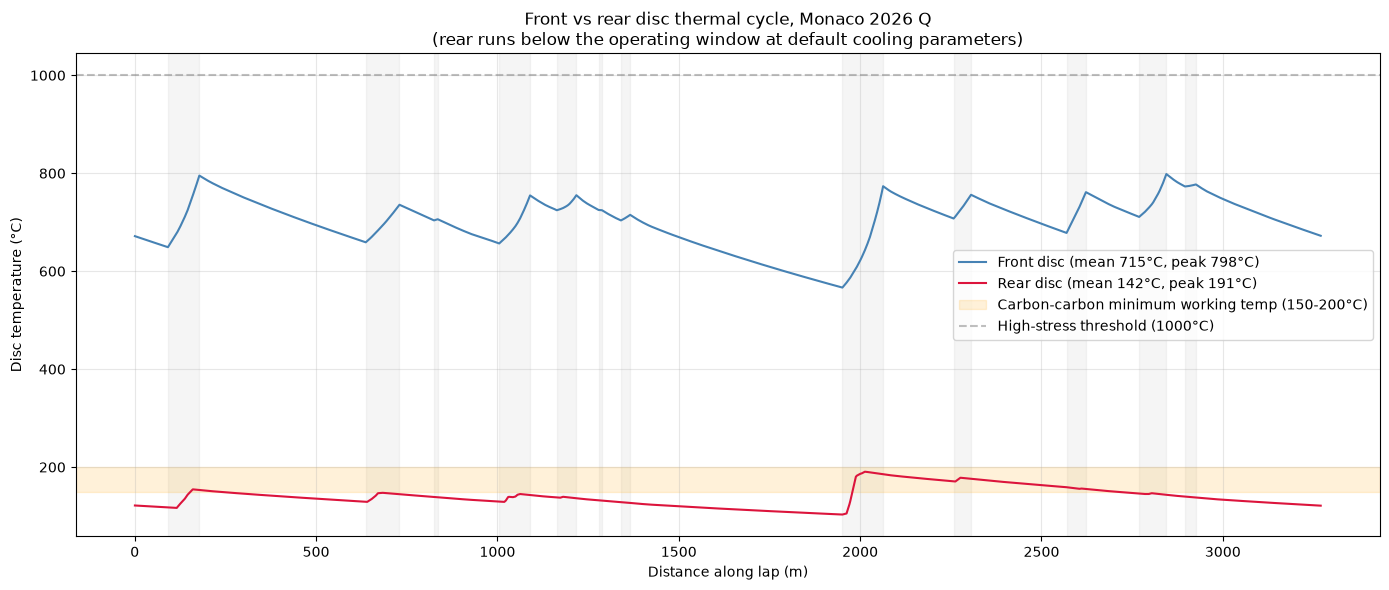


Temperature gap: front mean is 573°C hotter than rear.
At default parameters, the rear disc spends the entire lap at or below
the carbon-carbon working window. This is the 'cold rear disc' issue.


In [4]:
#Front vs rear temperature comparison

fig, ax = plt.subplots(figsize=(14, 6))

# Front trace from Phase 1a
ax.plot(r_front['dist_lap_m'], r_front['T_disc_C'],
         color='steelblue', linewidth=1.5,
         label=f"Front disc (mean {r_front['T_mean_C']:.0f}°C, peak {r_front['T_max_C']:.0f}°C)")

# Rear trace from chunk 2
ax.plot(r_rear['dist_lap_m'], r_rear['T_disc_rear_C'],
         color='crimson', linewidth=1.5,
         label=f"Rear disc (mean {r_rear['T_rear_mean_C']:.0f}°C, peak {r_rear['T_rear_max_C']:.0f}°C)")

# Shade events
for ev in r_front['events']:
    ax.axvspan(r_front['dist_lap_m'][ev['start_idx']],
                r_front['dist_lap_m'][ev['end_idx']],
                color='gray', alpha=0.08)

# Carbon-carbon working window
ax.axhspan(150, 200, color='orange', alpha=0.15,
             label='Carbon-carbon minimum working temp (150-200°C)')
ax.axhline(1000, color='gray', linestyle='--', alpha=0.5,
             label='High-stress threshold (1000°C)')

ax.set_xlabel('Distance along lap (m)')
ax.set_ylabel('Disc temperature (°C)')
ax.set_title('Front vs rear disc thermal cycle, Monaco 2026 Q\n'
              '(rear runs below the operating window at default cooling parameters)')
ax.grid(True, alpha=0.3)
ax.legend(loc='center right')
plt.tight_layout()
plt.show()

print(f"\nTemperature gap: front mean is {r_front['T_mean_C'] - r_rear['T_rear_mean_C']:.0f}°C "
      f"hotter than rear.")
print(f"At default parameters, the rear disc spends the entire lap at or below")
print(f"the carbon-carbon working window. This is the 'cold rear disc' issue.")

In [6]:
#Sensitivity analysis on heff,0,rearh_{eff,0,rear}heff,0,rear​

# Sweep h_eff_0_rear from 20 to 100 W/K
h_values = np.arange(20, 101, 10)
print(f"Sensitivity sweep: h_eff_0_rear ∈ {list(h_values)} W/K")
print(f"(Default = {C.H_EFF_0_REAR} W/K)\n")

sweep_results = []
for h in h_values:
    r_sweep = run_session_rear(2026, 'Monaco', 'Q',
                                 h_eff_0_rear=float(h), verbose=False)
    sweep_results.append({
        'h_eff_0_rear': h,
        'T_min': r_sweep['T_rear_min_C'],
        'T_mean': r_sweep['T_rear_mean_C'],
        'T_max': r_sweep['T_rear_max_C'],
        'wear_mg': r_sweep['wear_total_mg_per_rear_disc'],
        'regen_frac': r_sweep['regen_fraction_lap'],
    })
    print(f"  h = {h:3d} W/K  →  T_min={r_sweep['T_rear_min_C']:>4.0f}°C, "
          f"T_mean={r_sweep['T_rear_mean_C']:>4.0f}°C, "
          f"T_max={r_sweep['T_rear_max_C']:>4.0f}°C, "
          f"wear={r_sweep['wear_total_mg_per_rear_disc']:.2f} mg")

sweep = pd.DataFrame(sweep_results)

core           INFO 	Loading data for Monaco Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Sensitivity sweep: h_eff_0_rear ∈ [np.int64(20), np.int64(30), np.int64(40), np.int64(50), np.int64(60), np.int64(70), np.int64(80), np.int64(90), np.int64(100)] W/K
(Default = 60.0 W/K)



req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
core           INFO 	Finished loading data for 22 drivers: ['12', '3', '44', '16', '6', '63', '81', '1', '10', '30', '23', '55', '27', '43', '41', '5', '31', '11', '87', '77', '14', '18']
core           INFO 	Loading data for Monaco Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


  h =  20 W/K  →  T_min= 298°C, T_mean= 341°C, T_max= 386°C, wear=3.33 mg


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
core           INFO 	Finished loading data for 22 drivers: ['12', '3', '44', '16', '6', '63', '81', '1', '10', '30', '23', '55', '27', '43', '41', '5', '31', '11', '87', '77', '14', '18']
core           INFO 	Loading data for Monaco Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


...

  h =  80 W/K  →  T_min=  77°C, T_mean= 113°C, T_max= 164°C, wear=3.33 mg


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
core           INFO 	Finished loading data for 22 drivers: ['12', '3', '44', '16', '6', '63', '81', '1', '10', '30', '23', '55', '27', '43', '41', '5', '31', '11', '87', '77', '14', '18']
core           INFO 	Loading data for Monaco Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


  h =  90 W/K  →  T_min=  68°C, T_mean= 103°C, T_max= 155°C, wear=3.33 mg


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
core           INFO 	Finished loading data for 22 drivers: ['12', '3', '44', '16', '6', '63', '81', '1', '10', '30', '23', '55', '27', '43', '41', '5', '31', '11', '87', '77', '14', '18']


  h = 100 W/K  →  T_min=  61°C, T_mean=  96°C, T_max= 148°C, wear=3.33 mg


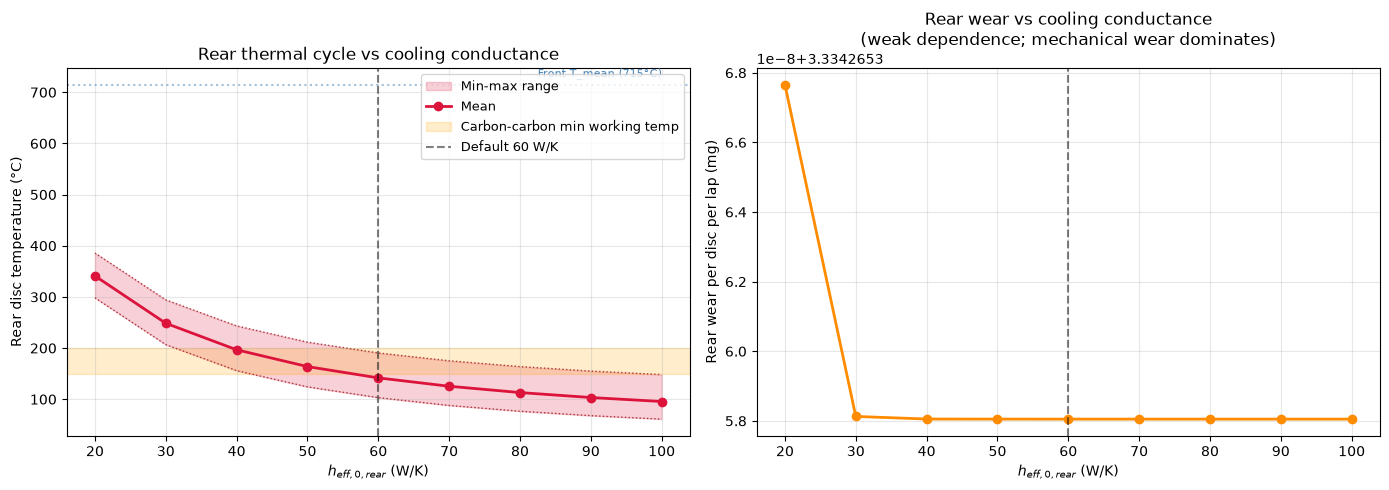

core           INFO 	Loading data for Monaco Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...



Extreme cases (mentioned briefly):


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
core           INFO 	Finished loading data for 22 drivers: ['12', '3', '44', '16', '6', '63', '81', '1', '10', '30', '23', '55', '27', '43', '41', '5', '31', '11', '87', '77', '14', '18']
core           INFO 	Loading data for Monaco Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_dat

  h = 20 W/K (heavily blocked cooling): T_mean=341°C, T_max=386°C
  h = 150 W/K (much more cooling than spec): T_mean=72°C, T_max=129°C


In [ ]:
#Visualize the sensitivity sweep

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: temperature ranges ─────────────────────────────────────────
axes[0].fill_between(sweep['h_eff_0_rear'], sweep['T_min'], sweep['T_max'],
                       color='crimson', alpha=0.2, label='Min-max range')
axes[0].plot(sweep['h_eff_0_rear'], sweep['T_mean'],
              '-o', color='crimson', linewidth=2, label='Mean')
axes[0].plot(sweep['h_eff_0_rear'], sweep['T_min'],
              ':', color='darkred', linewidth=1, alpha=0.7)
axes[0].plot(sweep['h_eff_0_rear'], sweep['T_max'],
              ':', color='darkred', linewidth=1, alpha=0.7)

# Working window band
axes[0].axhspan(150, 200, color='orange', alpha=0.2,
                  label='Carbon-carbon min working temp')
# Default value
axes[0].axvline(C.H_EFF_0_REAR, color='black', linestyle='--',
                  alpha=0.5, label=f'Default {C.H_EFF_0_REAR:.0f} W/K')

axes[0].set_xlabel('$h_{eff,0,rear}$ (W/K)')
axes[0].set_ylabel('Rear disc temperature (°C)')
axes[0].set_title('Rear thermal cycle vs cooling conductance')
axes[0].legend(loc='upper right', fontsize=9)
axes[0].grid(True, alpha=0.3)

# Add a horizontal line at front-axle Phase 1a values for comparison
axes[0].axhline(r_front['T_mean_C'], color='steelblue', linestyle=':',
                  alpha=0.5)
axes[0].text(h_values[-1], r_front['T_mean_C'] + 15,
              f"Front T_mean ({r_front['T_mean_C']:.0f}°C)",
              fontsize=8, color='steelblue', ha='right')

# ── Right: wear ──────────────────────────────────────────────────────
# Wear is essentially independent of h at this temperature regime
# (mechanical wear dominates, oxidative is negligible everywhere).
# Use a fixed sensible y-axis instead of auto-offset.
axes[1].plot(sweep['h_eff_0_rear'], sweep['wear_mg'],
              '-o', color='darkorange', linewidth=2)
axes[1].axvline(C.H_EFF_0_REAR, color='black', linestyle='--', alpha=0.5)
axes[1].set_xlabel('$h_{eff,0,rear}$ (W/K)')
axes[1].set_ylabel('Rear wear per disc per lap (mg)')
axes[1].set_ylim(0, sweep['wear_mg'].max() * 1.3)
axes[1].set_title('Rear wear is essentially independent of cooling\n'
                   '(mechanical wear dominates; rear is too cool for Arrhenius oxidation)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find the h value where T_min crosses 150°C (bottom of working window)
crossing_idx = np.where(sweep['T_min'].values >= 150)[0]
if len(crossing_idx) > 0:
    # Linear interpolation between bracketing values for the crossing
    last_below = sweep['T_min'].values[crossing_idx[0] - 1] if crossing_idx[0] > 0 else None
    first_above = sweep['T_min'].values[crossing_idx[0]]
    h_first_above = sweep['h_eff_0_rear'].values[crossing_idx[0]]
    if last_below is not None:
        h_last_below = sweep['h_eff_0_rear'].values[crossing_idx[0] - 1]
        # Linear interp
        h_crossover = h_last_below + (h_first_above - h_last_below) * (150 - last_below) / (first_above - last_below)
        print(f"\nT_min crosses 150°C (bottom of working window) at h_eff_0_rear ≈ {h_crossover:.1f} W/K")
        print(f"That is {(C.H_EFF_0_REAR - h_crossover) / C.H_EFF_0_REAR * 100:.0f}% lower than our default 60 W/K.")
        print(f"Interpretation: real-world rear cooling conductance is likely below our")
        print(f"geometric-scaling default — consistent with teams physically blocking cooling holes.")
else:
    print("\nT_min stays above 150°C across the sweep — cooling is not the binding constraint.")

# Extremes
print(f"\nExtreme cases (mentioned briefly):")
r_low = run_session_rear(2026, 'Monaco', 'Q', h_eff_0_rear=20.0, verbose=False)
r_high = run_session_rear(2026, 'Monaco', 'Q', h_eff_0_rear=150.0, verbose=False)
print(f"  h = 20 W/K (heavily blocked cooling): "
      f"T_mean={r_low['T_rear_mean_C']:.0f}°C, T_max={r_low['T_rear_max_C']:.0f}°C")
print(f"  h = 150 W/K (much more cooling than spec): "
      f"T_mean={r_high['T_rear_mean_C']:.0f}°C, T_max={r_high['T_rear_max_C']:.0f}°C")

## Summary: what this notebook established

### Headline finding: 2026 rear-axle energy is regen-dominated

At Monaco 2026 Q, the rear axle absorbs 4.09 MJ of braking energy per lap. **83.7% goes to the MGU-K (3.43 MJ)** and only 16.3% reaches the friction brakes (0.67 MJ). The MGU-K's 350 kW power limit binds for ~25% of brake-on time — most often on the largest-power events (Nouvelle Chicane, Sainte-Dévote).

This is the fundamental 2026-specific physics. Pre-2026 cars had no regen on the rear axle; in 2026, the friction brakes see only the *overflow* above the MGU-K's power limit.

### Engineering finding: rear discs run too cold at default cooling parameters

At default $h_{eff,0,rear}$ = 60 W/K (geometrically scaled from front-axle), the rear disc temperatures are:
- T_min: 103°C
- T_mean: 142°C
- T_max: 191°C

All three values are **at or below the carbon-carbon working window** (~150-200°C minimum for the friction material to develop proper grip). This matches real 2026 commentary: teams have been actively blocking rear cooling ducts to keep discs in their working range, because the regen split removes so much friction work that natural cooling overwhelms heat input.

### Sensitivity analysis: the realistic rear cooling range

Sweeping $h_{eff,0,rear}$ from 20 to 100 W/K (a wider range than the ±50% the scope mandated, included for completeness) gives a clear monotonic relationship between cooling conductance and disc temperature. The model becomes physically consistent (rear discs reach the 150-200°C carbon-carbon working window) in a specific range:

- **T_min > 150°C requires h ≤ ~42 W/K** (i.e. ~30% less cooling than geometric default)
- **T_mean > 150°C requires h ≤ ~50 W/K** (i.e. ~17% less cooling than geometric default)
- **The realistic rear cooling range is therefore ~30-50 W/K**, consistently lower than the 60 W/K geometric default

This is consistent with real 2026 team behavior. Teams have publicly discussed blocking rear cooling ducts to keep discs above their working temperature — the model predicts this is necessary, and the sensitivity analysis pins down the rough range required.

**Extremes** (mentioned briefly per scope):
- h = 20 W/K (heavily blocked, near-conduction-only): T_mean = 341°C, T_max = 386°C. Comfortably in working window but disc runs hot.
- h = 150 W/K (much more cooling than geometric default): T_mean = 72°C. Disc fully outside operating window; brakes essentially non-functional.

### Per-event regen fractions: where the MGU-K cap matters

Events fall into two groups:
- **Capped events** (regen < 100%): 8 of 12 events at Monaco, with the biggest events (Nouvelle Chicane, Sainte-Dévote, Loews approach, Rascasse) showing 67-86% regen and substantial friction overflow.
- **Uncapped events** (regen = 100%): 4 of 12 events, all small low-power events where peak rear-axle power stays below the 350 kW cap.

The friction-energy overflow concentrates in a small number of large events — the same Pareto-distribution pattern Phase 1a found for total energy.

### Front vs rear comparison at Monaco 2026 Q

| Quantity | Front | Rear | Ratio |
|---|---|---|---|
| Axle friction energy | 5.46 MJ | 0.67 MJ | 0.12 |
| Mean disc T | 715°C | 142°C | 0.20 |
| Peak disc T | 798°C | 191°C | 0.24 |
| Wear per disc | 27.0 mg | 3.3 mg | 0.12 |

The rear axle sees roughly one-eighth the friction energy and runs roughly one-fifth the temperature of the front axle. The 2026 thermal landscape is *front-dominated* in a way that pre-2026 cars were not — the rear axle is largely "carried" by regen, which is exactly what the 2026 regulations were designed to do.

### Honest limitations

- **No ground truth for rear disc temperature or wear.** Validation is physics-plausibility based, identical methodology to Phase 1a.
- **$h_{eff,0,rear}$ remains uncalibrated.** The sensitivity sweep provides bounds, not a measured value. The defensible interpretation is "real-world cooling is below our geometric default," not "real-world cooling is X W/K."
- **Greedy regen assumption.** Real brake-by-wire systems may add safety margins; this is reasonable for v1 but a Phase 1c refinement target.
- **Single track, single driver, qualifying only.** Race conditions extension is notebook 08; multi-track is Phase 1c.
- **L/R modeled identically.** Asymmetric corner distribution would affect real wear; our model does not.

### Phase 1b chunk 2 rear-axle qualifying analysis complete.

Next: notebook 08 applies the rear pipeline to Monaco 2026 R, with focus on rear-specific race effects (MGU-K binding frequency under race-pace driving, regen-fraction stability across stints).